In [22]:
import time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import metpy.calc as mpcalc
from metpy.interpolate import cross_section
import matplotlib.colors as mcolors
from metpy.units import units
import math
import matplotlib as mpl
import arrow
import pint
import pandas as pd
from scipy.spatial import distance
from scipy.interpolate import splprep, splev

In [23]:
initTime = '2024061412'
year = initTime[0:4]
month = initTime[4:6]
day = initTime[6:8]
hour = initTime[8:10]
fcHour = 0

In [24]:
source='ecmwf_fine_his'
baseUrl = 'http://10.148.8.71:7080/thredds/dodsC/{0}/'.format(source)
year = '2024'
month = '06'
urlRhum = baseUrl + '{0}{1}/rhum.nc'.format(year, month)
urlVectorX = baseUrl + '{0}{1}/uwnd.nc'.format(year, month)
urlVectorY = baseUrl + '{0}{1}/vwnd.nc'.format(year, month)
urlTemp = baseUrl + '{0}{1}/temp.nc'.format(year, month)
urlHght = baseUrl + '{0}{1}/hght.nc'.format(year, month)
urlSpre = baseUrl + '{0}{1}/spre.nc'.format(year, month)

In [25]:
dataSetRhum = xr.open_dataset(urlRhum)
dataSetVecX = xr.open_dataset(urlVectorX)
dataSetVecY = xr.open_dataset(urlVectorY)
dataSetTemp = xr.open_dataset(urlTemp)
dataSetHght = xr.open_dataset(urlHght)
dataSetSpre = xr.open_dataset(urlSpre)

In [26]:
selectedTime = '{0}-{1}-{2} {3}:00:00'.format(year, month, day, hour)
fcStr = '{:0>3d}'.format(fcHour)
rhumVarName = 'rhum{}'.format(fcStr)
vectorXVarName = 'uwnd{}'.format(fcStr)
vectorYVarName = 'vwnd{}'.format(fcStr)
tempVarName = 'temp{}'.format(fcStr)
hghtVarName = 'hght{}'.format(fcStr)
spreVarName = 'spre{}'.format(fcStr)

In [27]:
target_lev = 500
rhum = dataSetRhum[rhumVarName].sel(time=selectedTime, level=target_lev).to_dataset(name=rhumVarName)
uwnd = dataSetVecX[vectorXVarName].sel(time=selectedTime, level=target_lev).to_dataset(name=vectorXVarName)
vwnd = dataSetVecY[vectorYVarName].sel(time=selectedTime, level=target_lev).to_dataset(name=vectorYVarName)
temp = dataSetTemp[tempVarName].sel(time=selectedTime, level=target_lev).to_dataset(name=tempVarName)
hght = dataSetHght[hghtVarName].sel(time=selectedTime, level=target_lev).to_dataset(name=hghtVarName)
spre = dataSetSpre[spreVarName].sel(time=selectedTime, level=0.0).to_dataset(name=spreVarName)
rhum = rhum.metpy.parse_cf(varname=rhumVarName)
uwnd = uwnd.metpy.parse_cf(varname=vectorXVarName)
vwnd = vwnd.metpy.parse_cf(varname=vectorYVarName)
temp = temp.metpy.parse_cf(varname=tempVarName)
hght = hght.metpy.parse_cf(varname=hghtVarName)
spre = spre.metpy.parse_cf(varname=spreVarName)

In [28]:
latitude = uwnd.lat
longitude = uwnd.lon
gridUnit = (longitude[1] - longitude[0]).item()

In [29]:
# 1. 通过uwnd计算风速从南到北由正值转变为负值所对应的位置(dataArray的latitude从北到南排列）
sign_change_u = np.diff(np.sign(uwnd), axis=0)
shear_u_index = np.where(sign_change_u < 0) # 这将会返回latitude, longitude的索引位置，
# 2. 通过vwnd计算风速从西到东由负值转变为正值所对应的位置
sign_change_v = np.diff(np.sign(vwnd), axis=1) 
shear_v_index = np.where(sign_change_v > 0) # 这将会返回latitude, longitude的索引位置
# 根据索引值从经纬度数组中获取切变位置
shear_u_latitude = latitude[shear_u_index[0]] + gridUnit/2.0 # 由于diff函数会使得数组纬度维长度减一，因此需要减去gridUnit/2.0
shear_u_longitude = longitude[shear_u_index[1]]
shear_u = np.vstack([shear_u_latitude, shear_u_longitude]).T  # 垂直堆叠并转置，使每一行代表一个点的[latitude, longitude]

shear_v_latitude = latitude[shear_v_index[0]]
shear_v_longitude = longitude[shear_v_index[1]] + gridUnit/2.0 # 由于diff函数会使得数组经度维长度减一，因此需要加上gridUnit/2.0
shear_v = np.vstack([shear_v_latitude, shear_v_longitude]).T  # 垂直堆叠并转置，使每一行代表一个点的[latitude, longitude]


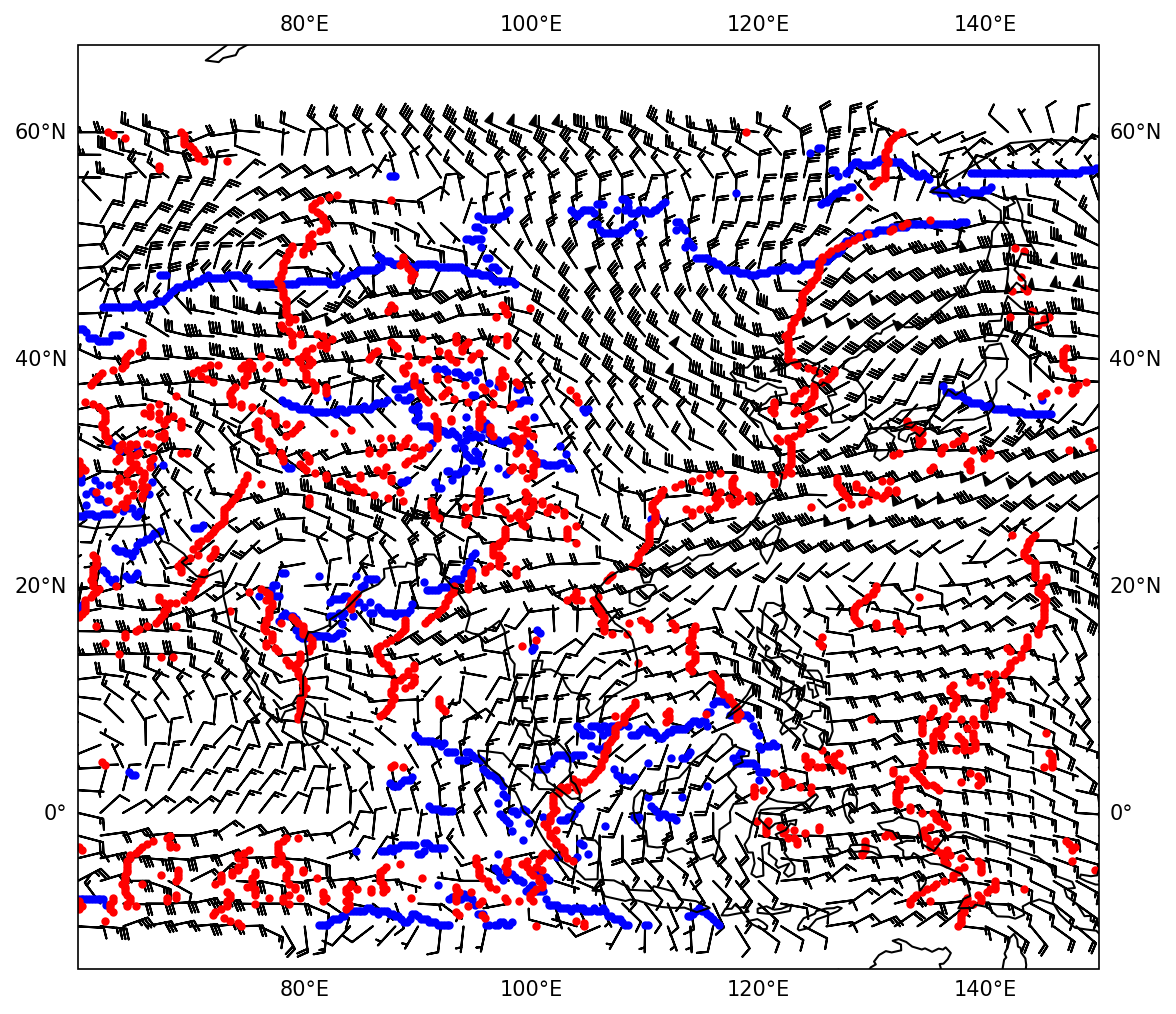

In [30]:
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([longitude[0], longitude[-1], latitude[0], latitude[-1]]) # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':') # 设置

# 添加风向杆图
skip = 8  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
# ax.scatter(shear_u[:, 1], shear_u[:, 0], color='r', label='Shear U', transform=ccrs.PlateCarree(),marker="_") # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
# ax.scatter(shear_v[:, 1], shear_v[:, 0], color='b', label='Shear V', transform=ccrs.PlateCarree(),marker="|")
ax.scatter(shear_u[:, 1], shear_u[:, 0], color='blue', label='Shear U', transform=ccrs.PlateCarree(),marker=".") # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.scatter(shear_v[:, 1], shear_v[:, 0], color='red', label='Shear V', transform=ccrs.PlateCarree(),marker=".")
ax.gridlines(draw_labels=True,linewidth=0)
# ax.legend()  # 添加图例
plt.show()

In [31]:
# 拆分shear_u为shear_u_left和shear_u_right
# shear_u_left: vwnd <= 0, shear_u_right: vwnd > 0
shear_u_left_mask = []
shear_u_right_mask = []

for i in range(len(shear_u)):
    lat_idx = shear_u_index[0][i]
    lon_idx = shear_u_index[1][i]
    # 获取该点的vwnd值
    vwnd_value = vwnd.values[lat_idx, lon_idx]
    if vwnd_value <= 0:
        shear_u_left_mask.append(True)
        shear_u_right_mask.append(False)
    else:
        shear_u_left_mask.append(False)
        shear_u_right_mask.append(True)

shear_u_left = shear_u[shear_u_left_mask]
shear_u_right = shear_u[shear_u_right_mask]

# 拆分shear_v为shear_v_up和shear_v_down
# shear_v_up: uwnd >= 0, shear_v_down: uwnd < 0
shear_v_up_mask = []
shear_v_down_mask = []

for i in range(len(shear_v)):
    lat_idx = shear_v_index[0][i]
    lon_idx = shear_v_index[1][i]
    # 获取该点的uwnd值
    uwnd_value = uwnd.values[lat_idx, lon_idx]
    if uwnd_value >= 0:
        shear_v_up_mask.append(True)
        shear_v_down_mask.append(False)
    else:
        shear_v_up_mask.append(False)
        shear_v_down_mask.append(True)

shear_v_up = shear_v[shear_v_up_mask]
shear_v_down = shear_v[shear_v_down_mask]

print(f"shear_u_left: {len(shear_u_left)} points")
print(f"shear_u_right: {len(shear_u_right)} points")
print(f"shear_v_up: {len(shear_v_up)} points")
print(f"shear_v_down: {len(shear_v_down)} points")

shear_u_left: 695 points
shear_u_right: 565 points
shear_v_up: 1023 points
shear_v_down: 710 points


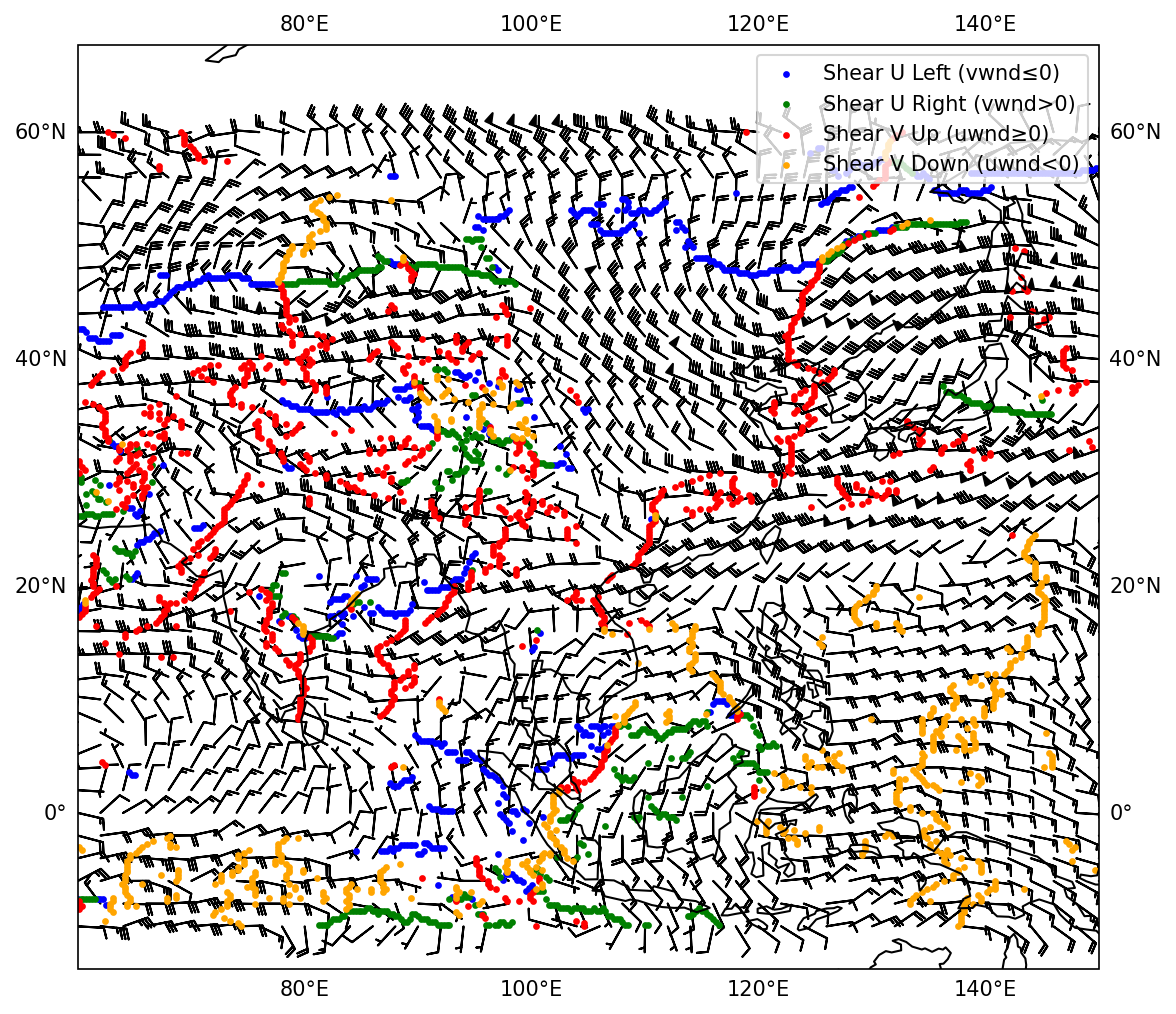

In [32]:
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([longitude[0], longitude[-1], latitude[0], latitude[-1]]) # 设置地图显示范围,格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':') # 设置

# 添加风向杆图
skip = 8  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加四种切变点的散点图,使用不同颜色
# shear_u_left: vwnd <= 0 (蓝色)
# shear_u_right: vwnd > 0 (绿色)
# shear_v_up: uwnd >= 0 (红色)
# shear_v_down: uwnd < 0 (橙色)
if len(shear_u_left) > 0:
    ax.scatter(shear_u_left[:, 1], shear_u_left[:, 0], color='blue', label='Shear U Left (vwnd≤0)', 
               transform=ccrs.PlateCarree(), marker=".", s=20)
if len(shear_u_right) > 0:
    ax.scatter(shear_u_right[:, 1], shear_u_right[:, 0], color='green', label='Shear U Right (vwnd>0)', 
               transform=ccrs.PlateCarree(), marker=".", s=20)
if len(shear_v_up) > 0:
    ax.scatter(shear_v_up[:, 1], shear_v_up[:, 0], color='red', label='Shear V Up (uwnd≥0)', 
               transform=ccrs.PlateCarree(), marker=".", s=20)
if len(shear_v_down) > 0:
    ax.scatter(shear_v_down[:, 1], shear_v_down[:, 0], color='orange', label='Shear V Down (uwnd<0)', 
               transform=ccrs.PlateCarree(), marker=".", s=20)

ax.gridlines(draw_labels=True,linewidth=0)
ax.legend(loc='upper right')  # 添加图例
plt.show()

In [33]:
# Function to calculate pairwise distances and form connections
def form_lines(points, interval_dis, length_min):
    num_points = len(points)
    visited = np.zeros(num_points, dtype=bool)
    lines = []

    for i in range(num_points):
        if visited[i]:
            continue
        
        # Start a new line with point i
        current_line = [points[i]]
        visited[i] = True
        
        while True:
            # Calculate distances to all unvisited points
            dists = distance.cdist([current_line[-1]], points[~visited], metric='euclidean')
            unvisited_indices = np.where(~visited)[0]
            
            # Find the nearest unvisited point within the threshold
            if len(dists[0]) == 0:
                break
            min_dist_idx = np.argmin(dists[0])
            min_dist = dists[0][min_dist_idx]
            
            if min_dist < interval_dis:
                # Add the nearest point to the line
                current_line.append(points[unvisited_indices[min_dist_idx]])
                visited[unvisited_indices[min_dist_idx]] = True
            else:
                break
        
        # Calculate the total length of the line
        total_length = sum(
            np.linalg.norm(np.array(current_line[i]) - np.array(current_line[i+1]))
            for i in range(len(current_line) - 1)
        )
        
        # Only add the line if it meets the minimum length criteria
        if total_length > length_min:
            lines.append(current_line)

    return lines# Function to calculate pairwise distances and form connections
def form_lines(points, interval_dis, length_min):
    num_points = len(points)
    visited = np.zeros(num_points, dtype=bool)
    lines = []

    for i in range(num_points):
        if visited[i]:
            continue
        
        # Start a new line with point i
        current_line = [points[i]]
        visited[i] = True
        
        while True:
            # Calculate distances to all unvisited points
            dists = distance.cdist([current_line[-1]], points[~visited], metric='euclidean')
            unvisited_indices = np.where(~visited)[0]
            
            # Find the nearest unvisited point within the threshold
            if len(dists[0]) == 0:
                break
            min_dist_idx = np.argmin(dists[0])
            min_dist = dists[0][min_dist_idx]
            
            if min_dist < interval_dis:
                # Add the nearest point to the line
                current_line.append(points[unvisited_indices[min_dist_idx]])
                visited[unvisited_indices[min_dist_idx]] = True
            else:
                break
        
        # Calculate the total length of the line
        total_length = sum(
            np.linalg.norm(np.array(current_line[i]) - np.array(current_line[i+1]))
            for i in range(len(current_line) - 1)
        )
        
        # Only add the line if it meets the minimum length criteria
        if total_length > length_min:
            lines.append(current_line)

    return lines

In [34]:
# Updated function to smooth lines with consistent return structure
def smooth_lines(lines, smoothness=0.5):
    smoothed_lines = []
    for line in lines:
        line = np.array(line)
        if len(line) > 2:  # Only interpolate lines with more than 2 points
            tck, u = splprep([line[:, 0], line[:, 1]], s=smoothness)  # Longitude, Latitude
            u_new = np.linspace(0, 1, 100)
            smoothed_points = np.array(splev(u_new, tck)).T  # Convert to Nx2 array: [[lon, lat], ...]
            smoothed_lines.append(smoothed_points)
        else:
            # If the line is too short, keep it as it is in the original format
            smoothed_lines.append(line)
    return smoothed_lines

def smooth_lines_Bezier(lines, num_points=100, num_control_points=None):
    """
    使用 Bezier 曲线平滑线段
    
    参数:
    - lines: list，线段列表
    - num_points: int，平滑后每条线的点数
    - num_control_points: int 或 None，贝塞尔曲线的控制点数量
                          如果为 None，则使用原始线段的所有点作为控制点
                          如果指定数量，则从原始点中均匀采样指定数量的控制点
    
    返回:
    - smoothed_lines: list，平滑后的线段列表
    """
    import scipy.special
    
    def bezier_curve(points, t):
        n = len(points) - 1
        return sum(
            scipy.special.comb(n, i) * (1 - t)**(n - i) * t**i * np.array(points[i])
            for i in range(n + 1)
        )

    smoothed_lines = []
    t_values = np.linspace(0, 1, num_points)

    for line in lines:
        if len(line) > 2:  # Only smooth lines with more than 2 points
            # 如果指定了控制点数量且小于原始点数，则进行采样
            if num_control_points is not None and num_control_points < len(line):
                # 确保控制点数量至少为2（起点和终点）
                num_control_points = max(2, num_control_points)
                # 从原始点中均匀采样指定数量的控制点
                indices = np.linspace(0, len(line) - 1, num_control_points, dtype=int)
                control_points = [line[i] for i in indices]
            else:
                # 使用所有原始点作为控制点
                control_points = line
            
            smoothed_lines.append([bezier_curve(control_points, t) for t in t_values])
        else:
            # If the line is too short, keep it as it is
            smoothed_lines.append(line)

    return smoothed_lines

In [35]:
# Parameters for connection rules
interval_dis = 2.5#0.6
length_min = 5.0
points = shear_v #np.array(list(zip(latitudes, longitudes)))
lines = form_lines(points, interval_dis, length_min)
print(lines)
# Smoothing lines using the defined function
# smoothness = 1.0
# lines = smooth_lines(lines, smoothness=smoothness)

[[array([-10.   ,  74.375], dtype=float32), array([-9.75 , 74.125], dtype=float32), array([-9.5  , 73.375], dtype=float32), array([-9.25 , 72.875], dtype=float32), array([-8.5  , 72.625], dtype=float32), array([-8.75 , 72.125], dtype=float32), array([-9.   , 71.875], dtype=float32), array([-8.25 , 73.125], dtype=float32), array([-8.   , 73.125], dtype=float32), array([-7.75 , 73.125], dtype=float32), array([-7.5  , 73.375], dtype=float32), array([-7.25 , 73.375], dtype=float32), array([-7.   , 73.125], dtype=float32), array([-6.   , 72.625], dtype=float32), array([-5.75 , 72.625], dtype=float32), array([-5.5  , 72.625], dtype=float32), array([-6.25 , 72.125], dtype=float32), array([-5.5  , 73.625], dtype=float32), array([-5.25 , 73.625], dtype=float32), array([-5.   , 74.125], dtype=float32), array([-4.75 , 74.125], dtype=float32), array([-4.5  , 74.625], dtype=float32), array([-4.25 , 74.625], dtype=float32), array([-4.   , 74.125], dtype=float32), array([-3.75 , 74.125], dtype=float3

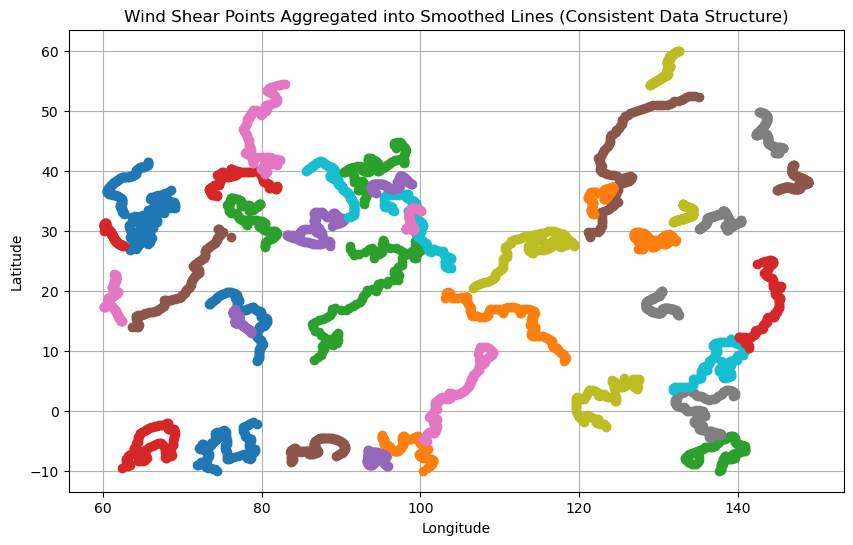

In [36]:
# Function to plot lines (either original or smoothed)
def plot_lines(lines, title='Wind Shear Points Aggregated into Lines', linewidth=0.5):
    plt.figure(figsize=(10, 6))
    for line in lines:
        line = np.array(line)
        plt.plot(line[:, 1], line[:, 0], marker='o', linewidth=linewidth)  # Longitude (x-axis), Latitude (y-axis)

    # Adding labels and title
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(title)
    plt.grid(True)
    plt.show()
smoothness_value = 0
smoothed_lines = smooth_lines(lines, smoothness=smoothness_value)
plot_lines(smoothed_lines, title='Wind Shear Points Aggregated into Smoothed Lines (Consistent Data Structure)', linewidth=0.5)

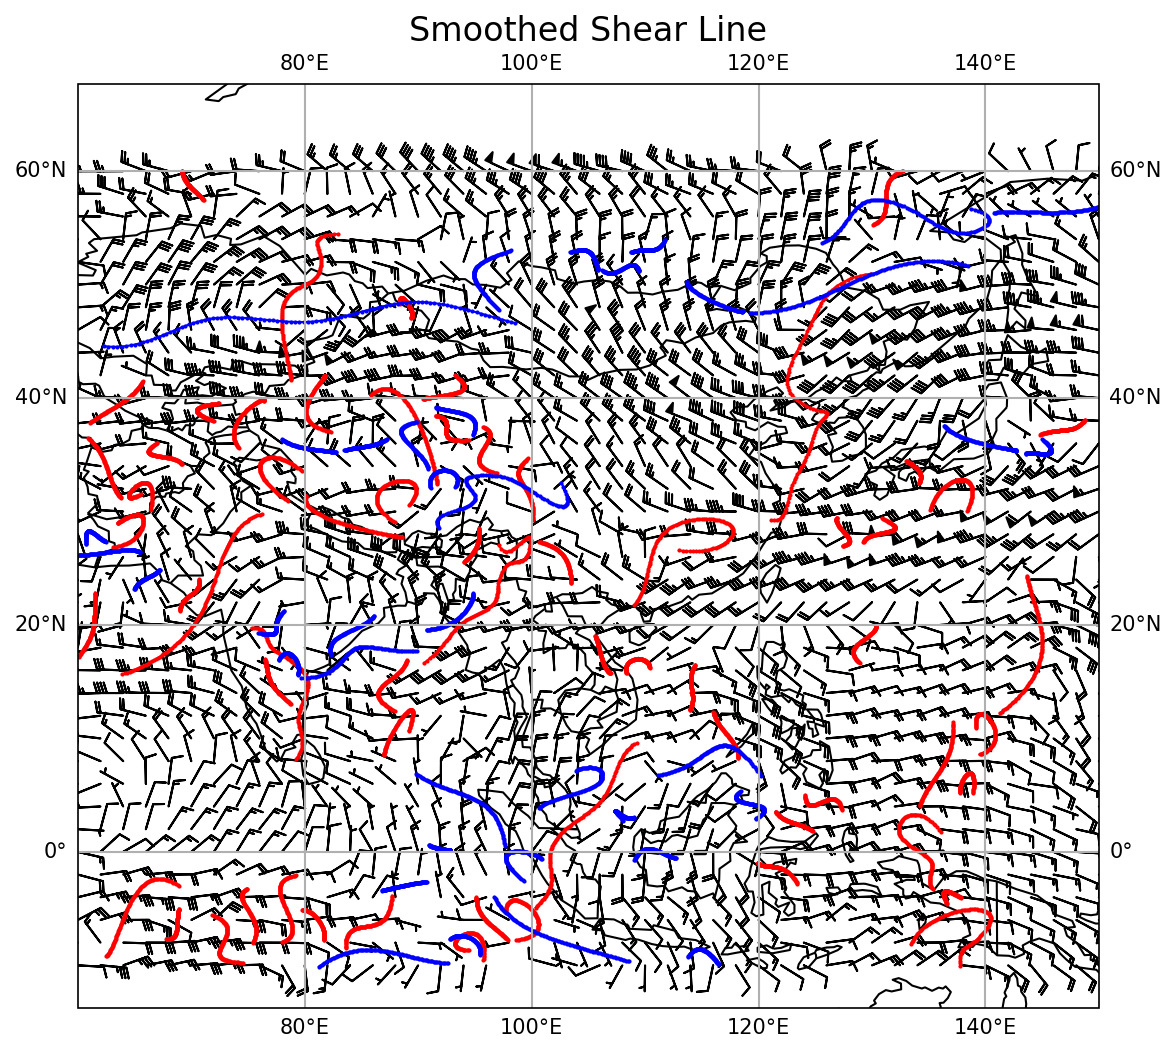

In [37]:


# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
map_projection = ccrs.PlateCarree()# ccrs.LambertConformal(central_longitude=100, central_latitude=35)
# ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax = fig.add_subplot(1, 1, 1, projection=map_projection)
# 设置为lambert投影，并设置显示范围中央经线100


ax.set_extent([longitude[0], longitude[-1], latitude[0], latitude[-1]]) # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS) # 设置

# 添加涡度
# levels = np.linspace(0, 10, 10)
# cf = ax.contourf(longitude, latitude, vorticity, levels=levels, extend='max', transform=ccrs.PlateCarree(), cmap='spring_r')
# plt.colorbar(cf, ax=ax, label='Vorticity')

# 添加风向杆图
skip = 8  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})
# Parameters for connection rules
interval_dis = 1.5#1.0
length_min = 3#2
smoothness = 6#1  # Example smoothness parameter
# Converting latitudes and longitudes to numpy arrays for easier manipulation

# v 方向切变线
points = shear_v #np.array(list(zip(latitudes, longitudes)))
lines = form_lines(points, interval_dis, length_min)
# Smoothing lines using the defined function

lines = smooth_lines(lines, smoothness=smoothness)
for line in lines:
    line = np.array(line)
    plt.plot(line[:, 1], line[:, 0], marker='o', linewidth=1, markersize=1, color='red')  # Longitude (x-axis), Latitude (y-axis)

# u 方向切变线
points = shear_u #np.array(list(zip(latitudes, longitudes)))
lines = form_lines(points, interval_dis, length_min)
lines = smooth_lines(lines, smoothness=smoothness)
for line in lines:
    line = np.array(line)
    plt.plot(line[:, 1], line[:, 0], marker='o', linewidth=1.0, markersize=1, color='blue')  # Longitude (x-axis), Latitude (y-axis)
ax.gridlines(draw_labels=True,linewidth=1)
# ax.legend()  # 添加图例
plt.title('Smoothed Shear Line', fontsize=16)  # 添加标题
plt.show()

In [38]:
def add_meteorological_attributes(lines,  u10, v10):
    """
    为槽线添加气象相关属性并输出每条槽线。

    参数:
    - lines: list，槽线的点集合，每条线是[[lat1, lon1], [lat2, lon2], ...]。
    - u10, v10: xarray.Dataset 或 xarray.DataArray，10米风速的经向和纬向分量。

    返回:
    - result: list，每条槽线和对应的属性，格式为：
      {
          "line": [[lat1, lon1], [lat2, lon2], ...],
          "attributes": {
              "region_box": {...},
              "length": ...,
              "avg_vorticity": ...,
              "avg_wind_speed": ...
          }
      }
    """
    # 从 Dataset 中提取 DataArray（如果是 Dataset 的话）
    if isinstance(u10, xr.Dataset):
        u10 = u10[list(u10.data_vars)[0]]
    if isinstance(v10, xr.Dataset):
        v10 = v10[list(v10.data_vars)[0]]
    
    # 为风速数据添加单位（如果没有单位的话）
    if not hasattr(u10.data, 'units'):
        u10 = u10 * units('m/s')
    if not hasattr(v10.data, 'units'):
        v10 = v10 * units('m/s')
    
    vorticity = mpcalc.vorticity(u10, v10)* 1e5
    result = []
    for line in lines:
        line = np.array(line)
        lats, lons = line[:, 0], line[:, 1]

        # 1. 计算region_box属性
        region_box = {
            "min_lat": lats.min(),
            "max_lat": lats.max(),
            "min_lon": lons.min(),
            "max_lon": lons.max()
        }

        # 2. 计算槽线长度
        length = np.sum(
            np.sqrt(
                (np.diff(lats) ** 2) + (np.diff(lons) ** 2)
            )
        )

        # 3. 计算平均涡度
        avg_vorticity = []
        for lat, lon in zip(lats, lons):
            vort_val = vorticity.sel(lat=lat, lon=lon, method="nearest")
            # 处理单位（如果有的话）
            if hasattr(vort_val, 'magnitude'):
                avg_vorticity.append(vort_val.magnitude)
            else:
                avg_vorticity.append(vort_val.values)
        avg_vorticity = np.mean(avg_vorticity)

        # 4. 计算平均风速
        avg_wind_speed = []
        for lat, lon in zip(lats, lons):
            u = u10.sel(lat=lat, lon=lon, method="nearest")
            v = v10.sel(lat=lat, lon=lon, method="nearest")
            # 处理单位（如果有的话）
            if hasattr(u, 'magnitude'):
                u_val = u.magnitude
                v_val = v.magnitude
            else:
                u_val = u.values
                v_val = v.values
            avg_wind_speed.append(np.sqrt(u_val ** 2 + v_val ** 2))
        avg_wind_speed = np.mean(avg_wind_speed)

        # 5. 计算夹角 (起点-中点-终点)
        if len(line) >= 3:
            start = line[0]
            middle = line[len(line) // 2]  # 中间点
            end = line[-1]

            # 计算向量
            vec1 = middle - start
            vec2 = end - middle

            # 计算向量的模
            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)

            # 防止除零
            if norm1 == 0 or norm2 == 0:
                angle = np.nan  # 弧度制
            else:
                # 计算向量夹角
                dot_product = np.dot(vec1, vec2)
                angle = np.arccos(np.clip(dot_product / (norm1 * norm2), -1.0, 1.0))
        else:
            angle = np.nan  # 如果点数少于3，无法计算夹角

        # 转换为角度制
        angle = np.degrees(angle) if not np.isnan(angle) else angle

        # 保存槽线及其属性
        result.append({
            "line": line,
            "attributes": {
                "region_box": region_box,
                "length": length,
                "avg_vorticity": avg_vorticity,
                "avg_wind_speed": avg_wind_speed,
                "angle": angle
            }
        })
    return result

In [39]:
def convert_to_dataframe(result):
    """
    将槽线结果转换为DataFrame，并按照avg_vorticity从大到小排序。

    参数:
    - result: list，每条槽线及其属性的结果列表。

    返回:
    - sorted_df: pandas.DataFrame，包含槽线及其属性的数据，按照avg_vorticity排序。
    """
    # 将结果转换为DataFrame
    data = []
    for idx, item in enumerate(result):
        data.append({
            "line_index": idx + 1,
            "line": item["line"],
            "region_box": item["attributes"]["region_box"],
            "length": item["attributes"]["length"],
            "avg_vorticity": item["attributes"]["avg_vorticity"],
            "avg_wind_speed": item["attributes"]["avg_wind_speed"],
            "angle": item["attributes"]["angle"],

        })

    df = pd.DataFrame(data)

    # 按照 avg_vorticity 从大到小排序
    sorted_df = df.sort_values(by="avg_vorticity", ascending=False).reset_index(drop=True)

    return sorted_df

# 转换并排序
lines_attr = add_meteorological_attributes(lines, uwnd, vwnd)
df_lines = convert_to_dataframe(lines_attr)
df_lines

,line_index,line,region_box,length,avg_vorticity,avg_wind_speed,angle
0,31,"[[47.53151184435955, 119.24846111415926], [47....","{'min_lat': 47.52379791290962, 'max_lat': 52.0...",20.017231,11.725678,4.564040,8.699237
1,28,"[[35.36312619813236, 142.72278583186346], [35....","{'min_lat': 35.36312619813236, 'max_lat': 37.5...",6.830820,10.852435,5.638566,12.897117
2,27,"[[35.38677142789995, 83.4803711617391], [35.39...","{'min_lat': 35.38677142789995, 'max_lat': 36.3...",3.941632,9.704332,6.522568,8.269322
3,23,"[[32.09576464940155, 91.09881596256123], [32.1...","{'min_lat': 32.09576464940155, 'max_lat': 33.6...",4.582599,7.336309,3.178402,108.787197
4,38,"[[56.340493679222774, 140.76429298605373], [56...","{'min_lat': 56.340493679222774, 'max_lat': 56....",9.290248,6.604650,2.101078,6.549847
5,25,"[[35.2080786244512, 82.7844122929911], [35.217...","{'min_lat': 35.2080786244512, 'max_lat': 36.35...",4.973481,6.432839,3.151340,11.640353
6,18,"[[19.575700354643804, 90.75342461829979], [19....","{'min_lat': 19.575700354643804, 'max_lat': 22....",5.659826,5.971612,3.565764,38.752064
7,26,"[[35.10114833392701, 143.54212658314066], [35....","{'min_lat': 35.09711547004462, 'max_lat': 36.3...",3.711776,5.438935,5.384785,107.319662
8,34,"[[51.24372530818121, 106.24234877796803], [51....","{'min_lat': 51.01593891997365, 'max_lat': 51.7...",3.750298,5.266885,6.532815,19.540806
9,30,"[[44.57992841613992, 62.2676639606004], [44.53...","{'min_lat': 44.519273163703566, 'max_lat': 48....",37.114406,5.016311,5.955817,7.081058


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


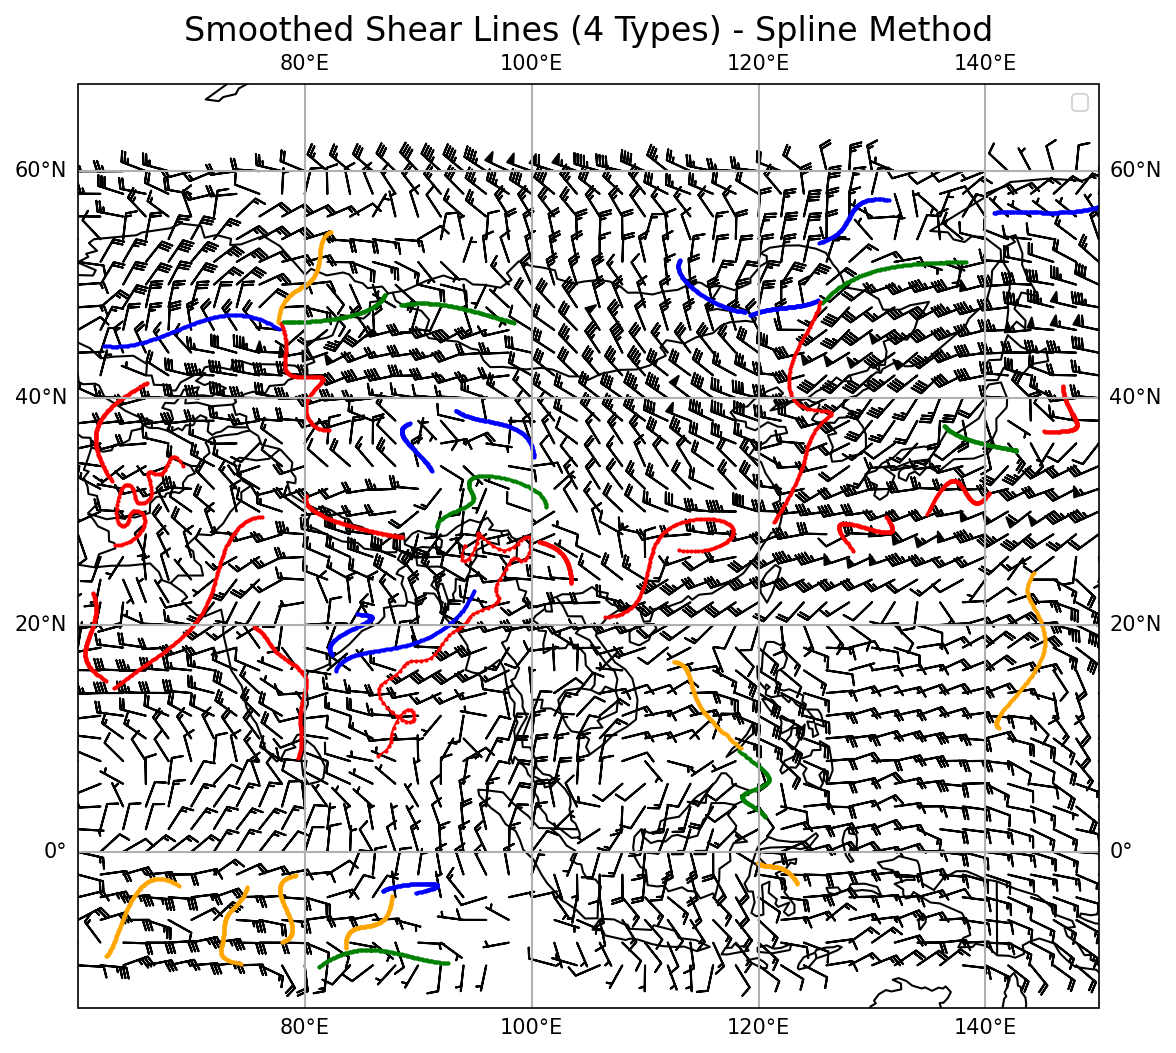

In [40]:
def process_and_plot_shear_lines(points, interval_dis, length_min, smoothness,
                                  vorticity_threshold, wind_speed_threshold,
                                  angle_threshold, color, linewidth, label, ax,
                                  smooth_method='spline', num_points=100, num_control_points=None):
    """
    处理切变点数据并绘制切变线的通用函数

    参数:
    - points: 切变点数组
    - interval_dis: 连接阈值距离
    - length_min: 最小线段长度
    - smoothness: 平滑参数（用于spline方法）
    - vorticity_threshold: 涡度过滤阈值
    - wind_speed_threshold: 风速过滤阈值
    - angle_threshold: 角度过滤阈值
    - color: 绘图颜色
    - linewidth: 线宽
    - label: 图例标签
    - ax: matplotlib轴对象
    - smooth_method: str, 平滑方法，可选 'spline' 或 'bezier'，默认 'spline'
    - num_points: int, 平滑后的点数（用于bezier方法），默认100
    - num_control_points: int 或 None, 贝塞尔曲线的控制点数量（仅用于bezier方法），默认为None（使用所有点）
    """
    lines = form_lines(points, interval_dis, length_min)
    lines_attr = add_meteorological_attributes(lines, uwnd, vwnd)
    df_lines = convert_to_dataframe(lines_attr)

    # 过滤条件
    filtered_df = df_lines[
        (df_lines['avg_vorticity'] > vorticity_threshold) &
        (df_lines['avg_wind_speed'] > wind_speed_threshold) &
        (df_lines['angle'] < angle_threshold)
    ].reset_index(drop=True)

    # 根据选择的方法进行平滑处理
    if smooth_method == 'bezier':
        smoothed_lines = smooth_lines_Bezier(filtered_df['line'], num_points=num_points, 
                                             num_control_points=num_control_points)
    else:  # 默认使用 spline
        smoothed_lines = smooth_lines(filtered_df['line'], smoothness=smoothness)

    # 绘制
    for line in smoothed_lines:
        line = np.array(line)
        ax.plot(line[:, 1], line[:, 0], marker='o', linewidth=linewidth,
                markersize=1, color=color, label=label if line is smoothed_lines[0] else '')

# 创建地图
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([longitude[0], longitude[-1], latitude[0], latitude[-1]])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# 添加风向杆图
skip = 8
ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip],
         transform=ccrs.PlateCarree(), length=5,
         barb_increments={'half':2, 'full':4, 'flag':20}, sizes={'emptybarb':0})

# 参数设置
interval_dis = 2.0
length_min = 6
smoothness = 6
smooth_method = 'spline'  # 可选 'spline' 或 'bezier'
num_points = 100  # Bezier曲线点数（平滑后的点数）
num_control_points = 6  # Bezier曲线控制点数量（None表示使用所有原始点）

# 处理并绘制四种切变线
# shear_u_left: vwnd <= 0 (蓝色)
process_and_plot_shear_lines(shear_u_left, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=2.0,
                              angle_threshold=90, color='blue', linewidth=1.0,
                              label='Shear U Left', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_u_right: vwnd > 0 (绿色)
process_and_plot_shear_lines(shear_u_right, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=2.0,
                              angle_threshold=90, color='green', linewidth=1.0,
                              label='Shear U Right', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_v_up: uwnd >= 0 (红色)
process_and_plot_shear_lines(shear_v_up, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=3.0,
                              angle_threshold=90, color='red', linewidth=1.0,
                              label='Shear V Up', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_v_down: uwnd < 0 (橙色)
process_and_plot_shear_lines(shear_v_down, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=3.0,
                              angle_threshold=90, color='orange', linewidth=1.0,
                              label='Shear V Down', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

ax.gridlines(draw_labels=True, linewidth=1)
ax.legend(loc='upper right')
plt.title(f'Smoothed Shear Lines (4 Types) - {smooth_method.capitalize()} Method', fontsize=16)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


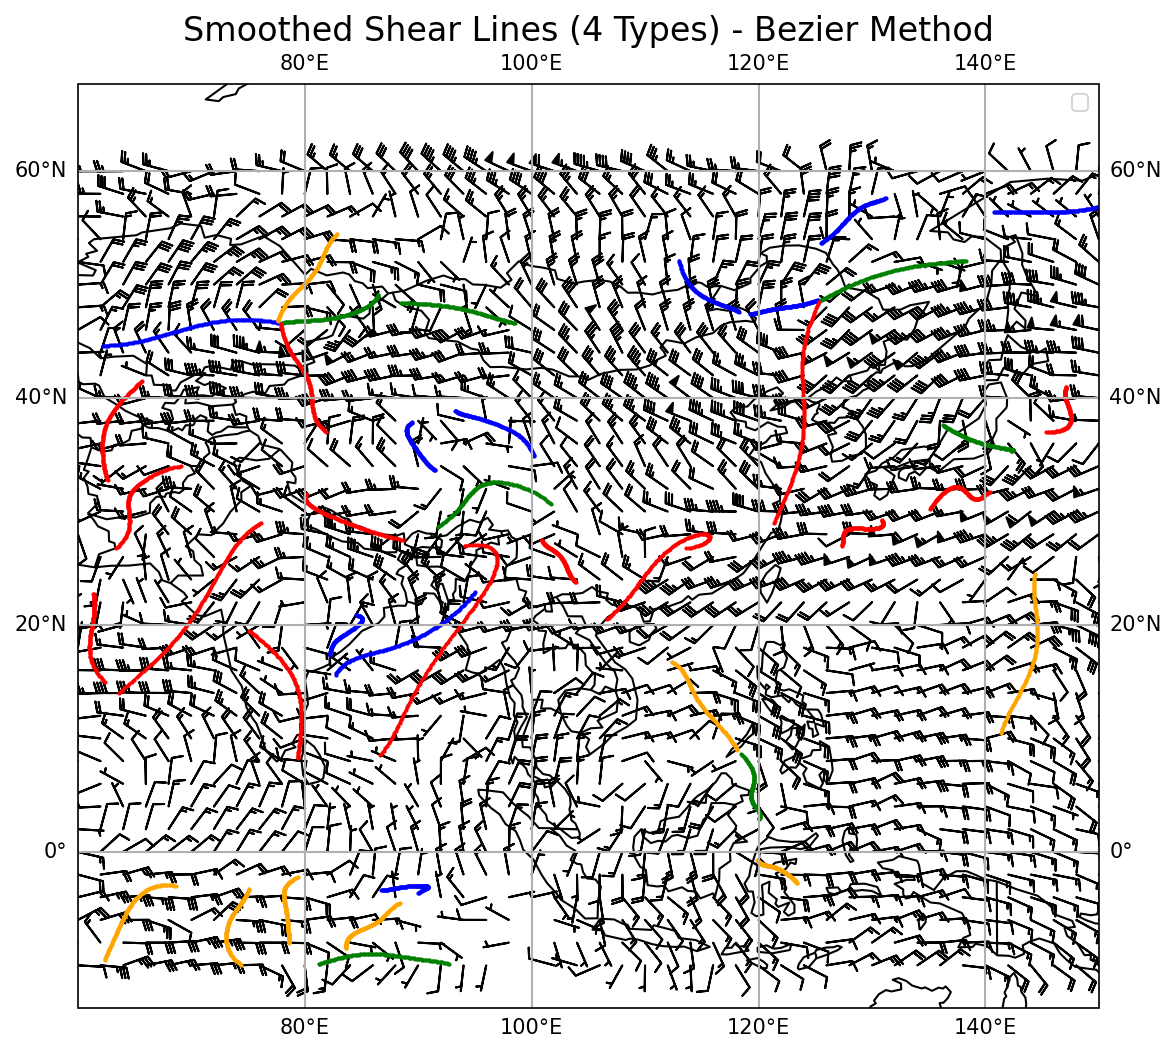

In [42]:
# 创建地图
fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([longitude[0], longitude[-1], latitude[0], latitude[-1]])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# 添加风向杆图
skip = 8
ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip],
         transform=ccrs.PlateCarree(), length=5,
         barb_increments={'half':2, 'full':4, 'flag':20}, sizes={'emptybarb':0})

# 参数设置
interval_dis = 2.0
length_min = 6
smoothness = 6
smooth_method = 'bezier'  # 可选 'spline' 或 'bezier'
num_points = 100  # Bezier曲线点数（平滑后的点数）
num_control_points = 7  # Bezier曲线控制点数量（控制曲线的复杂度，数值越小曲线越平滑）

# 处理并绘制四种切变线
# shear_u_left: vwnd <= 0 (蓝色)
process_and_plot_shear_lines(shear_u_left, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=2.0,
                              angle_threshold=90, color='blue', linewidth=1.0,
                              label='Shear U Left', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_u_right: vwnd > 0 (绿色)
process_and_plot_shear_lines(shear_u_right, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=2.0,
                              angle_threshold=90, color='green', linewidth=1.0,
                              label='Shear U Right', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_v_up: uwnd >= 0 (红色)
process_and_plot_shear_lines(shear_v_up, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=3.0,
                              angle_threshold=90, color='red', linewidth=1.0,
                              label='Shear V Up', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

# shear_v_down: uwnd < 0 (橙色)
process_and_plot_shear_lines(shear_v_down, interval_dis, length_min, smoothness,
                              vorticity_threshold=1.0, wind_speed_threshold=3.0,
                              angle_threshold=90, color='orange', linewidth=1.0,
                              label='Shear V Down', ax=ax,
                              smooth_method=smooth_method, num_points=num_points,
                              num_control_points=num_control_points)

ax.gridlines(draw_labels=True, linewidth=1)
ax.legend(loc='upper right')
plt.title(f'Smoothed Shear Lines (4 Types) - {smooth_method.capitalize()} Method', fontsize=16)
plt.show()